## Luyện tập

### 1. Luyện tập 1:

In [ ]:
def T(n):
  if n == 0 or n == 1:
    return 2
  sum = 0
  for i in range(1, n):
    sum += 2 * T(i) * T(i - 1)
  return sum
for n in range(5):
    print(f"T({n}) = {T(n)}")

T(0) = 2
T(1) = 2
T(2) = 8
T(3) = 40
T(4) = 680


In [ ]:
def T_DP(n):
  if n < 0:
    raise ValueError("n must be non-negative")
  T = [0] * (n + 1)
  if n >= 0:
        T[0] = 2
  if n >= 1:
        T[1] = 2
  for i in range(2, n + 1):
        total = 0
        for j in range(1, i):
            total += 2 * T[j] * T[j-1]
        T[i] = total

  return T[n]
for n in range(5):
    print(f"T({n}) = {T_DP(n)}")

T(0) = 2
T(1) = 2
T(2) = 8
T(3) = 40
T(4) = 680


## Bài tập:

### Bài tập 1:

#### 1. Bài toán xếp tổ hợp

**Ý tưởng**:
- Sử dụng công thức $C(n, k) = C(n-1, k-1) + C(n-1, k)$
- Trường hợp cơ bản:
  - $C(n, 0) = 1$ (Chọn 0 phần tử)
  - $C(n,n) = 1$ (Chọn tất cả phần tử)
  - $C(n, k) = 0$ nếu k < 0 hoặc k > n
- Tạo bảng DP để lưu các giá trị $C(n, k)$ đã tính để không tính lại

In [ ]:
def combination(n, k):
    # Khởi tạo bảng DP với kích thước (n+1) x (k+1)
    dp = [[0] * (k + 1) for _ in range(n + 1)]

    # Trường hợp cơ bản: C(i, 0) = 1
    for i in range(n + 1):
        dp[i][0] = 1

    # Trường hợp cơ bản: C(i, i) = 1
    for i in range(n + 1):
        if i <= k:
            dp[i][i] = 1

    # Tính các giá trị C(n, k)
    for i in range(1, n + 1):
        for j in range(1, min(i, k) + 1):
            dp[i][j] = dp[i-1][j-1] + dp[i-1][j]

    return dp[n][k]

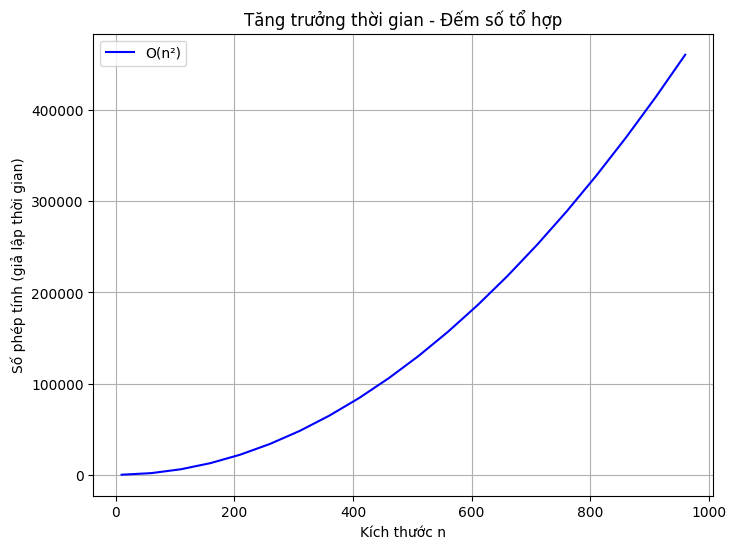

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Giả lập thời gian dựa trên O(n²) với k = n/2
n_values = np.arange(10, 1001, 50)
times = [n * (n // 2) for n in n_values]  # Giả lập số phép tính

plt.figure(figsize=(8, 6))
plt.plot(n_values, times, label="O(n²)", color="blue")
plt.xlabel("Kích thước n")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - Đếm số tổ hợp")
plt.grid(True)
plt.legend()
plt.show()

#### 2. Cho dãy số a gồm n phần tử. Tìm dãy con đơn điệu tăng dài nhất của a.

**Ý tưởng:**
- Sử dụng mảng `dp` để lưu độ dài của LIS kết thúc tại chỉ số `i`.
- Với mỗi phần tử `a[i]`, kiểm tra các phần tử trước đó `a[j]` (j < i). Nếu `a[j] < a[i]`, cập nhật `dp[i]` bằng cách lấy tối đa giữa `dp[i]` hiện tại và `dp[j] + 1`.
- Để in ra dãy con, lưu thêm mảng prev để theo dõi chỉ số trước đó trong dãy LIS.
- Kết quả là giá trị lớn nhất trong dp và dãy con được xây dựng lại từ prev.

In [ ]:
def longest_increasing_subsequence(a):
    n = len(a)
    if n == 0:
        return []

    # dp[i]: độ dài LIS kết thúc tại i
    dp = [1] * n
    # prev[i]: chỉ số phần tử trước i trong LIS
    prev = [-1] * n

    # Tìm LIS
    max_len = 1
    max_index = 0
    for i in range(1, n):
        for j in range(i):
            if a[j] < a[i] and dp[j] + 1 > dp[i]:
                dp[i] = dp[j] + 1
                prev[i] = j
        if dp[i] > max_len:
            max_len = dp[i]
            max_index = i

    # Khôi phục dãy con
    result = []
    while max_index != -1:
        result.append(a[max_index])
        max_index = prev[max_index]

    return result[::-1]

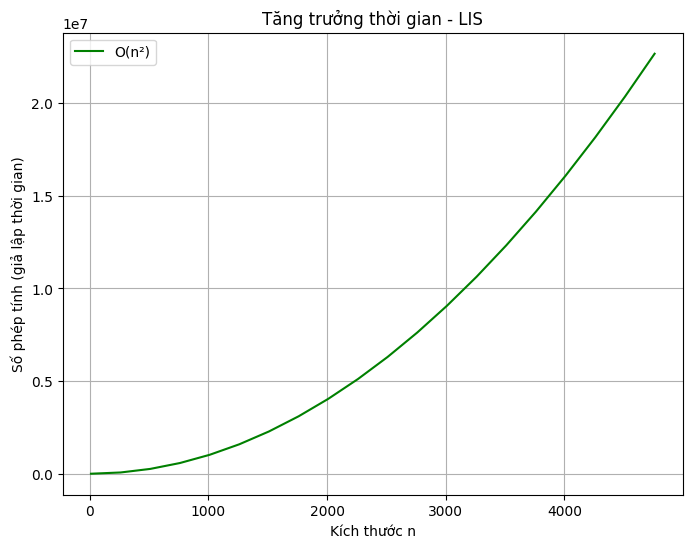

In [ ]:
# Giả lập thời gian dựa trên O(n²)
n_values = np.arange(10, 5001, 250)
times = [n ** 2 for n in n_values]

plt.figure(figsize=(8, 6))
plt.plot(n_values, times, label="O(n²)", color="green")
plt.xlabel("Kích thước n")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - LIS")
plt.grid(True)
plt.legend()
plt.show()

#### 3. Bài toán cái túi (0 - 1 Knapsack).

**Ý tưởng:**
- Sử dụng bảng DP 2 chiều `dp[i][j]`, trong đó:
  - `i`: Xem xét i vật phẩm đầu tiên (từ 0 đến i - 1)
  - `j`: dung lượng túi còn lại.
  - `dp[i][j]`: giá trị lớn nhất có thể đạt được khi xem xét i vật phẩm với dung lượng j.
- Công thức lặp:
  - Nếu không chọn vật phẩm thứ i: `dp[i][j] = dp[i-1][j]`.
  - Nếu chọn vật phẩm thứ i (nếu `w[i-1] <= j`): `dp[i][j] = dp[i-1][j-w[i-1] + v[i-1]`.
  - Lấy max của 2 trường hợp.
- Kết quả là `dp[n][W]`.

In [ ]:
def knapsack(W, weights, values, n):
    # Khởi tạo bảng DP
    dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]

    # Điền bảng DP
    for i in range(1, n + 1):
        for j in range(W + 1):
            if weights[i-1] <= j:
                dp[i][j] = max(dp[i-1][j], dp[i-1][j - weights[i-1]] + values[i-1])
            else:
                dp[i][j] = dp[i-1][j]

    # Truy vết để tìm các vật phẩm được chọn
    selected_items = []
    w = W
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i-1][w]:
            selected_items.append(i-1)
            w -= weights[i-1]

    return dp[n][W], selected_items[::-1]

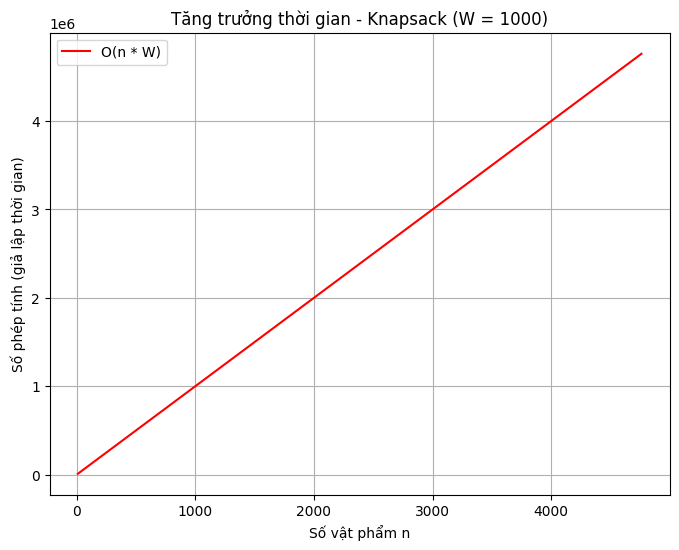

In [ ]:
# Giả lập thời gian dựa trên O(n * W), cố định W = 1000
W = 1000
n_values = np.arange(10, 5001, 250)
times = [n * W for n in n_values]

plt.figure(figsize=(8, 6))
plt.plot(n_values, times, label="O(n * W)", color="red")
plt.xlabel("Số vật phẩm n")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - Knapsack (W = 1000)")
plt.grid(True)
plt.legend()
plt.show()

#### 4. Cho xâu X có độ dài m, xâu Y có độ dài n. Tìm xâu con chung của X và Y có độ dài lớn nhất.

**Ý tưởng:**
- Sử dụng bảng DP 2 chiều `dp[i][j]` để lưu độ dài xâu con chung dài nhất kết thúc tại `X[i-1]` và `Y[j-1]`.
- Nếu `X[i-1] == Y[j-1]`, thì `dp[i][j] = dp[i-1][j-1] + 1`.
- Nếu không, `dp[i][j] = 0` (vì xâu con chung phải liên tục).
- Theo dõi độ dài lớn nhất và vị trí kết thúc để khôi phục xâu con chung.
- Kết quả là xâu con chung có độ dài lớn nhất.

In [ ]:
def longest_common_substring(X, Y):
    m, n = len(X), len(Y)
    # Khởi tạo bảng DP
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Biến lưu độ dài và vị trí kết thúc
    max_length = 0
    end_index = 0

    # Điền bảng DP
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i-1] == Y[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
                if dp[i][j] > max_length:
                    max_length = dp[i][j]
                    end_index = i
            else:
                dp[i][j] = 0

    # Khôi phục xâu con chung
    result = X[end_index - max_length:end_index]
    return max_length, result

In [ ]:
X = "ABCDGH"
Y = "ACDGHR"
length, substring = longest_common_substring(X, Y)
print(f"Độ dài xâu con chung dài nhất: {length}")
print(f"Xâu con chung: {substring}")

Độ dài xâu con chung dài nhất: 4
Xâu con chung: CDGH


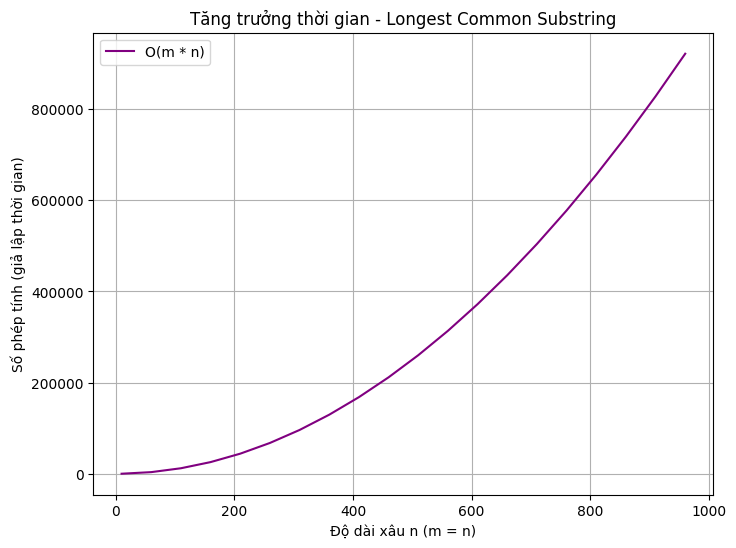

In [ ]:
# Giả lập thời gian dựa trên O(m * n), giả sử m = n
n_values = np.arange(10, 1001, 50)
times = [n * n for n in n_values]

plt.figure(figsize=(8, 6))
plt.plot(n_values, times, label="O(m * n)", color="purple")
plt.xlabel("Độ dài xâu n (m = n)")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - Longest Common Substring")
plt.grid(True)
plt.legend()
plt.show()

#### 5. Có $n$ cuộc họp, cuộc họp thứ $i$ bắt đầu tại thời điểm $s_i$ và kết thúc tại thời điểm $f_i$. Cuộc họp $i$ được bố trí trước cuộc họp $j$ nếu thời điểm kết thúc của cuộc họp $i$ nhỏ hơn hoặc bằng thời điểm bắt đầu $j$ (tức là $f_i$ ≤ $s_j$). Hãy bố trí phòng họp để phục vụ được nhiều cuộc họp nhất.

**Ý tưởng:**
- Sắp xếp các cuộc họp theo thời điểm kết thúc `(fi)` tăng dần. Nếu thời điểm kết thúc bằng nhau, ưu tiên cuộc họp bắt đầu sớm hơn.
- Chọn cuộc họp đầu tiên (kết thúc sớm nhất) và loại bỏ các cuộc họp xung đột với nó (tức là các cuộc họp có `sj ≤ fi`).
- Tiếp tục chọn cuộc họp tiếp theo không xung đột với cuộc họp đã chọn, cho đến khi không còn cuộc họp nào có thể chọn.
- Kết quả là danh sách các cuộc họp được chọn, đảm bảo số lượng tối đa.

In [ ]:
def max_meetings(start, end, n):
    # Tạo danh sách các cuộc họp với (start, end, index)
    meetings = [(start[i], end[i], i) for i in range(n)]

    # Sắp xếp theo thời điểm kết thúc (end), nếu bằng thì theo thời điểm bắt đầu (start)
    meetings.sort(key=lambda x: (x[1], x[0]))

    # Danh sách các cuộc họp được chọn
    selected = []
    last_end_time = -1

    # Duyệt qua các cuộc họp đã sắp xếp
    for meeting in meetings:
        start_time, end_time, index = meeting
        # Nếu thời điểm bắt đầu lớn hơn thời điểm kết thúc của cuộc họp trước
        if start_time >= last_end_time:
            selected.append(index)
            last_end_time = end_time

    return selected

In [ ]:
start = [1, 3, 0, 5, 8, 5]
end = [2, 4, 6, 7, 9, 9]
n = len(start)

result = max_meetings(start, end, n)
print(f"Số cuộc họp tối đa: {len(result)}")
print(f"Chỉ số các cuộc họp được chọn: {result}")

Số cuộc họp tối đa: 4
Chỉ số các cuộc họp được chọn: [0, 1, 3, 4]


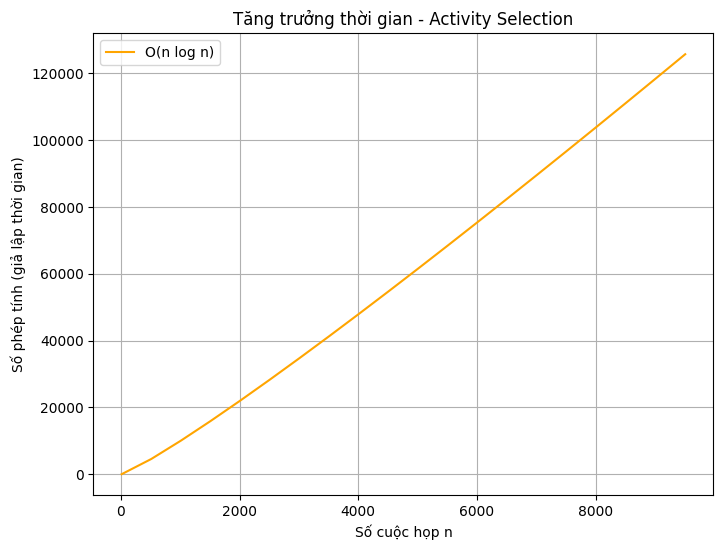

In [ ]:
# Giả lập thời gian dựa trên O(n log n)
n_values = np.arange(10, 10001, 500)
times = [n * np.log2(n) for n in n_values]

plt.figure(figsize=(8, 6))
plt.plot(n_values, times, label="O(n log n)", color="orange")
plt.xlabel("Số cuộc họp n")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - Activity Selection")
plt.grid(True)
plt.legend()
plt.show()

#### 6. (Cho thuê máy) Trung tâm tính toán hiệu năng cao nhận được đơn đặt hàng của $n$ khách hàng. Khách hàng $i$ muốn sử dụng máy trong khoảng thời gian từ $a_i$ đến $b_i$ và trả tiền thuê là $c_i$. Hãy bố trí lịch thuê máy để tổng số tiền thu được là lớn nhất mà thời gian sử dụng máy của 2 khách hàng bất kì được phục vụ đều không giao nhau (cả trung tâm chỉ có một máy cho thuê).

**Ý tưởng:**
- Sắp xếp các khách hàng theo thời điểm kết thúc(`bi`) tăng dần để dễ xử lý.
- Dùng mảng `dp[i]` để lưu tổng số tiền tối đa có thể thu được khi xem xét i khách hàng đầu tiên (từ 0 đến i-1).
- Với mỗi khách hàng i:
  - Có 2 lựa chọn:
    - **Không chọn** khách hàng i: `dp[i] = dp[i-1]`.
    - **Chọn** khách hàng i: Tìm khách hàng j gần nhất (j < i) mà khoảng cách thời gian của j không giao nhau với i (tức là `b[j] <= a[i]`), rồi lấy `dp[j] + c[i]`.
  - Lấy max của hai lựa chọn trên.
- Để tìm j nhanh chóng, có thể dùng tìm kiếm nhị phân để xác định khách hàng cuối cùng không giao nhau với i.
- Kết quả là `dp[n]`, và có thể truy vết để lấy danh sách khách hàng được chọn.

In [ ]:
def max_rental_profit(n, start, end, profit):
    # Tạo danh sách các khách hàng với (start, end, profit, index)
    jobs = [(start[i], end[i], profit[i], i) for i in range(n)]

    # Sắp xếp theo thời điểm kết thúc
    jobs.sort(key=lambda x: x[1])

    # Mảng dp lưu tổng lợi nhuận tối đa
    dp = [0] * (n + 1)
    # Mảng prev lưu chỉ số khách hàng trước đó được chọn
    prev = [-1] * n

    # Điền bảng dp
    for i in range(1, n + 1):
        # Không chọn khách hàng i-1
        dp[i] = dp[i-1]
        prev[i-1] = -1

        # Tìm khách hàng j gần nhất không giao nhau với i-1
        j = i - 2
        while j >= 0 and jobs[j][1] > jobs[i-1][0]:
            j -= 1
        # Nếu tìm được j, thử chọn khách hàng i-1
        if j >= -1:
            if dp[j + 1] + jobs[i-1][2] > dp[i]:
                dp[i] = dp[j + 1] + jobs[i-1][2]
                prev[i-1] = j

    # Truy vết để tìm các khách hàng được chọn
    selected = []
    i = n - 1
    while i >= 0:
        if prev[i] != -1 or (i > 0 and dp[i + 1] > dp[i]) or (i == 0 and dp[1] > 0):
            selected.append(jobs[i][3])
            i = prev[i]
        else:
            i -= 1

    return dp[n], selected[::-1]

In [ ]:
start = [1, 3, 0, 5, 8, 5]
end = [2, 4, 6, 7, 9, 9]
profit = [10, 20, 100, 70, 50, 30]
n = len(start)

max_profit, selected_jobs = max_rental_profit(n, start, end, profit)
print(f"Tổng số tiền tối đa: {max_profit}")
print(f"Chỉ số các khách hàng được chọn: {selected_jobs}")

Tổng số tiền tối đa: 150
Chỉ số các khách hàng được chọn: [2, 4]


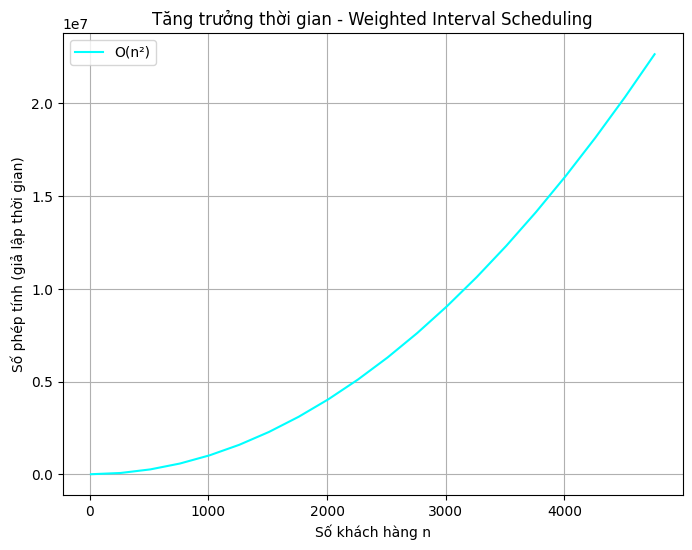

In [ ]:
# Giả lập thời gian dựa trên O(n²)
n_values = np.arange(10, 5001, 250)
times = [n ** 2 for n in n_values]

plt.figure(figsize=(8, 6))
plt.plot(n_values, times, label="O(n²)", color="cyan")
plt.xlabel("Số khách hàng n")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - Weighted Interval Scheduling")
plt.grid(True)
plt.legend()
plt.show()

#### 7. (Xếp các khối đá) Cho $N$ khối đá ($N$ ≤ 5000). Các khối đá đều có dạng hình hộp chữ nhật và được đặc trưng bới 3 kích thước: dài, rộng, cao. Một cách xây dựng tháp là một cách đặt một số các khối đá trong các khối đá đã cho chồng lên nhau theo quy tắc:
####- Chiều cao mỗi khối đá là kích thước nhỏ nhất trong 3 kích thước.
####- Các mép của khối đá được đặt song song với nhau sao cho không có phần nào của khối trên nằm chìa ra ngoài khối dưới.

#### Hãy chỉ ra cách để xây dựng được một cái tháp sao cho số khối đá được dùng là nhiều nhất.

**Ý tưởng:**
1. Xử lý khối đá:
- Mỗi khối đá có 3 kích thước (dài, rộng, cao). Vì chiều cao là kích thước nhỏ nhất và các khối có thể xoay, ta coi mỗi khối đá có thể tạo ra 6 cách sắp xếp (do hoán vị dài, rộng, cao, với cao là kích thước nhỏ nhất trong ba kích thước tại mỗi lần xoay).
- Tuy nhiên, để đơn giản, ta chỉ cần đảm bảo rằng mỗi khối được biểu diễn bằng (dài, rộng, cao) sao cho cao là nhỏ nhất, và dài ≥ rộng (để chuẩn hóa, tránh trùng lặp).
2. Ràng buộc xếp chồng:
- Khối trên `(l1, w1, h1)` có thể đặt lên khối dưới `(l2, w2, h2)` nếu:
  - `l1 ≤ l2` và `w1 ≤ w2` (hoặc ngược lại nếu xoay, nhưng ta chuẩn hóa để đơn giản).
- Điều này có nghĩa là khối trên phải hoàn toàn nằm trong mặt phẳng của khối dưới.
3. Bài toán LIS:
- Sau khi chuẩn hóa các khối đá thành danh sách các bộ `(l, w, h)`, sắp xếp chúng theo thứ tự giảm dần của `(l, w)` (để đảm bảo nếu khối i có thể đặt lên khối j thì i phải xuất hiện sau j trong danh sách).
- Tìm dãy con dài nhất sao cho mỗi khối trong dãy thỏa mãn điều kiện xếp chồng (tức là `l[i] ≤ l[j]` và `w[i] ≤ w[j]` với i đứng sau j).
Độ dài của dãy này là số khối đá tối đa có thể xếp.
4. Lập trình động:
- Dùng mảng `dp[i]` để lưu số khối đá tối đa có thể xếp khi xem xét đến khối thứ i và khối i là khối trên cùng.
- Với mỗi khối i, kiểm tra các khối j (j < i) mà khối i có thể đặt lên j, cập nhật `dp[i] = max(dp[j] + 1)` nếu thỏa mãn.
- Kết quả là giá trị lớn nhất trong mảng `dp`.

In [ ]:
def max_stone_tower(N, stones):
    # Tạo danh sách các khối đá với mọi cách xoay
    blocks = []
    for i in range(N):
        l, w, h = stones[i]
        # Lấy tất cả các hoán vị, chọn chiều cao nhỏ nhất
        perms = [(l, w, h), (l, h, w), (w, l, h), (w, h, l), (h, l, w), (h, w, l)]
        for x, y, z in perms:
            # Chuẩn hóa: chiều cao nhỏ nhất, dài >= rộng
            if x >= y:
                blocks.append((x, y, z, i))
            else:
                blocks.append((y, x, z, i))

    # Sắp xếp theo (dài, rộng) giảm dần
    blocks.sort(reverse=True)
    m = len(blocks)  # Số lượng khối sau khi tạo hoán vị

    # Mảng dp lưu số khối tối đa khi kết thúc tại i
    dp = [1] * m
    # Mảng prev để truy vết
    prev = [-1] * m

    # Tìm LIS dựa trên điều kiện xếp chồng
    max_len = 1
    max_index = 0
    for i in range(1, m):
        for j in range(i):
            # Kiểm tra nếu khối i có thể đặt lên khối j
            if blocks[i][0] <= blocks[j][0] and blocks[i][1] <= blocks[j][1]:
                if dp[j] + 1 > dp[i]:
                    dp[i] = dp[j] + 1
                    prev[i] = j
        if dp[i] > max_len:
            max_len = dp[i]
            max_index = i

    # Truy vết để lấy danh sách khối
    result = []
    while max_index != -1:
        result.append(blocks[max_index][3])  # Lấy chỉ số khối đá gốc
        max_index = prev[max_index]

    return max_len, result[::-1]

In [ ]:
N = 3
stones = [(1, 2, 3), (2, 3, 4), (3, 4, 5)]
max_height, selected_stones = max_stone_tower(N, stones)
print(f"Số khối đá tối đa: {max_height}")
print(f"Chỉ số các khối đá được chọn: {selected_stones}")

Số khối đá tối đa: 18
Chỉ số các khối đá được chọn: [2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]


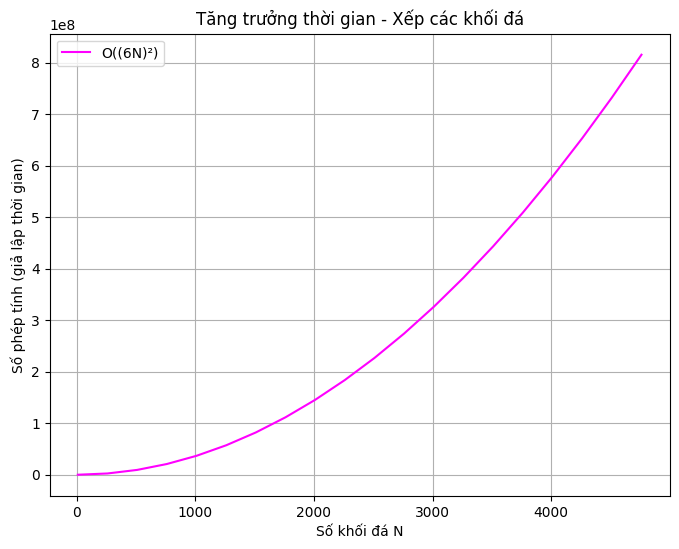

In [ ]:
# Giả lập thời gian dựa trên O(N²)
N_values = np.arange(10, 5001, 250)
times = [(6 * N) ** 2 for N in N_values]  # Tính với 6N khối

plt.figure(figsize=(8, 6))
plt.plot(N_values, times, label="O((6N)²)", color="magenta")
plt.xlabel("Số khối đá N")
plt.ylabel("Số phép tính (giả lập thời gian)")
plt.title("Tăng trưởng thời gian - Xếp các khối đá")
plt.grid(True)
plt.legend()
plt.show()

### Bài tập 2:

#### 1. Cho 2 xâu $X$, $Y$ . Hãy tìm xâu con của $X$ và của $Y$ có độ dài lớn nhất. Biết xâu con của một xâu thu được khi xóa một số kí tự thuộc xâu đó (hoặc không xóa kí tự nào).

**Phân tích bài toán**

**Định nghĩa:**
- Cho hai xâu X (độ dài m) và Y (độ dài n).
- Một xâu con chung là một chuỗi ký tự xuất hiện trong cả X và Y, theo đúng thứ tự (nhưng không nhất thiết liên tục).
- Mục tiêu: Tìm xâu con chung có độ dài lớn nhất.

**Thiết kế giải thuật**
**Ý tưởng:**
- Sử dụng bảng DP 2 chiều `dp[i][j]` để lưu độ dài của LCS của `X[0..i-1]` và `Y[0..j-1]`.
- Công thức lặp:
  - Nếu `X[i-1] == Y[j-1]`: `dp[i][j] = dp[i-1][j-1] + 1` (thêm ký tự chung vào LCS).
  - Nếu `X[i-1] != Y[j-1]`: `dp[i][j] = max(dp[i-1][j], dp[i][j-1])` (lấy LCS dài hơn từ hai khả năng).
- **Truy vết:**  Để khôi phục xâu con chung, lưu đường đi khi điền bảng DP hoặc duyệt ngược từ `dp[m][n]` để xây dựng xâu.
- Kết quả:
  - Độ dài LCS: `dp[m][n]`.
  - Xâu con chung: Truy vết từ bảng DP.

**Độ phức tạp:**
- **Thời gian:** `O(m * n)` để điền bảng DP.
- **Truy vết:** `O(m + n)` để xây dựng xâu con chung.

In [ ]:
def longest_common_subsequence(X, Y):
    m, n = len(X), len(Y)

    # Khởi tạo bảng DP
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Điền bảng DP
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i-1] == Y[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    # Truy vết để tìm xâu con chung
    lcs = []
    i, j = m, n
    while i > 0 and j > 0:
        if X[i-1] == Y[j-1]:
            lcs.append(X[i-1])
            i -= 1
            j -= 1
        elif dp[i-1][j] >= dp[i][j-1]:
            i -= 1
        else:
            j -= 1

    # Đảo ngược xâu vì truy vết từ cuối
    return dp[m][n], "".join(lcs[::-1])

In [ ]:
X = "ABCDGH"
Y = "AEDFHR"
length, lcs = longest_common_subsequence(X, Y)
print(f"Độ dài xâu con chung dài nhất: {length}")
print(f"Xâu con chung: {lcs}")

Độ dài xâu con chung dài nhất: 3
Xâu con chung: ADH


#### 2. **(Expression)** Cho n số nguyên. Hãy chia chúng thành 2 nhóm sao cho tích của tổng 2 nhóm là lớn nhất.

**Phân tích bài toán**

**Định nghĩa:**
- Cho danh sách gồm n số nguyên: $a_1, a_2,...,a_n$
- Chia danh sach thành 2 nhóm (có thể rỗng hoặc không) sao cho nếu tổng của nhóm 1 là $S_1$ và tổng của nhóm 2 là $S_2$, thì tích $S_1 * S_2$ là lớn nhất
- Hai nhóm không cần có số phần tử bằng nhau, và mỗi số chỉ thuộc một nhóm (hoặc nhóm 1 hoặc nhóm 2)

**Ví dụ:**
- Đầu vào: $[1,2,3,4]$.
- Cách cách chia:
  - Nhóm 1: $[1,2]$ (tổng = 3), Nhóm 2: $[3,4]$ (tổng = 7) -> Tích = 3 * 7 = 21
  - Nhóm 1: $[1,3]$ (tổng = 4), Nhóm 2: $[2,4]$ (tổng = 6) -> Tích = 4 * 6 = 24
  - Nhóm 1: [1,2,3]$$ (tổng = 6), Nhóm 2: $[4]$ (tổng = 4) -> Tích = 6 * 4 = 24
- Đầu ra: Tích lớn nhất = 24 (có thể đạt được với nhiều cách chia, ví dụ: $[1,3]$ và $[2,4]$)

**Giải thuật**

**Ý tưởng:**
- Gọi $S = 𝚺a_i$ là tổng tất cả các số.
- Dùng bảng DP để lưu tổng khả thi của tập hợp con:
  - $dp[i][j]$: Có thể đạt được tổng $j$ hay không khi xem xét i số đầu tiên.
- Sau khi có tất cả các tổng khả thi, duyệt qua các giá trị $S_1$ từ 0 đến $S$ và tính tích $S_1 * (S - S_1)$, lấy giá trị lớn nhất.

**Độ phức tạp:**
  - Thời gian: O(n * S'), với S' là tổng duyệt đối tối đa có thể đạt được.

In [3]:
import random
import time
import matplotlib.pyplot as plt

def max_product_of_sums(nums):
    n = len(nums)
    if n == 0:
        return 0

    # Tính tổng tất cả các số
    S = sum(nums)

    # Tìm giá trị nhỏ nhất và lớn nhất của tổng tập hợp con
    S_min = min(0, min(nums))  # Tổng nhỏ nhất có thể âm
    S_max = max(0, max(nums))  # Tổng lớn nhất có thể dương
    for num in nums:
        S_min = min(S_min, S_min + num)
        S_max = max(S_max, S_max + num)

    # Khởi tạo mảng DP 1 chiều để tối ưu không gian
    possible_sums = set([0])  # Tập hợp các tổng khả thi
    for i in range(n):
        new_sums = set()
        for s in possible_sums:
            new_sums.add(s)  # Không chọn nums[i]
            new_sums.add(s + nums[i])  # Chọn nums[i]
        possible_sums = new_sums

    # Tìm tích lớn nhất
    max_product = float('-inf')
    for S1 in possible_sums:
        S2 = S - S1
        max_product = max(max_product, S1 * S2)

    return max_product

In [2]:
nums = [1, 2, 3, 4]
result = max_product_of_sums(nums)
print(f"Tích lớn nhất của tổng hai nhóm: {result}")

Tích lớn nhất của tổng hai nhóm: 25


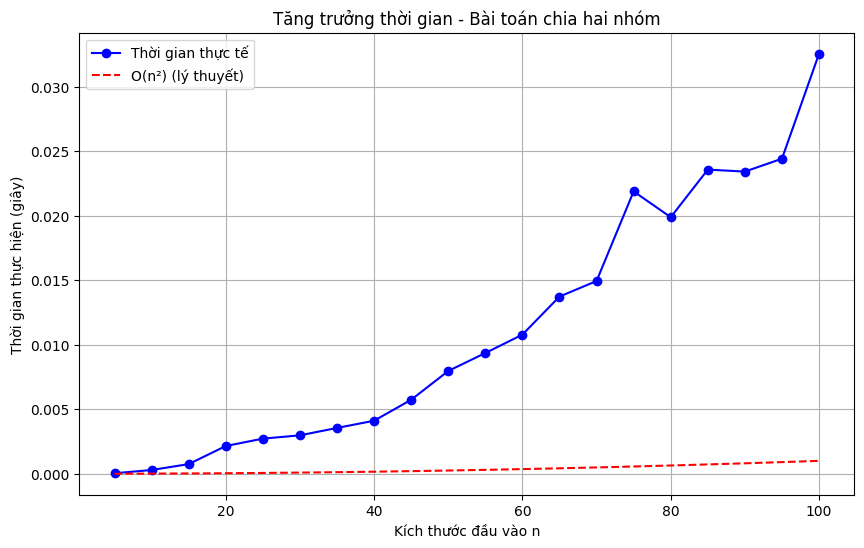

In [5]:
n_values = list(range(5, 101, 5))
times = []

for n in n_values:
    nums = [random.randint(-100, 100) for _ in range(n)]

    start_time = time.time()
    max_product_of_sums(nums)
    end_time = time.time()
    times.append(end_time - start_time)

plt.figure(figsize=(10, 6))
plt.plot(n_values, times, marker='o', label='Thời gian thực tế', color='blue')

theoretical_times = [0.0000001 * n ** 2 for n in n_values]  # Hệ số nhỏ để khớp với thời gian thực
plt.plot(n_values, theoretical_times, label='O(n²) (lý thuyết)', color='red', linestyle='--')

plt.xlabel('Kích thước đầu vào n')
plt.ylabel('Thời gian thực hiện (giây)')
plt.title('Tăng trưởng thời gian - Bài toán chia hai nhóm')
plt.grid(True)
plt.legend()
plt.show()

